<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Sewanee_Lidar_ALS_9_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prep Working Folders

Note thse files and processsing is "heavy" so we are using GDrive instead of the temp Colab space. This is to help with checkpoints in files. If the ram crashes the expored files can be grabbed form GDrive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pwd

/content


In [3]:
!mkdir /content/drive/MyDrive/GEDI_LAS_Comp

Note this folder cna be detleted at the end of the training  

In [2]:
%cd /content/drive/MyDrive/GEDI_LAS_Comp

/content/drive/MyDrive/GEDI_LAS_Comp


In [5]:
!pwd

/content/drive/MyDrive/GEDI_LAS_Comp


In [6]:
path = "/content/drive/MyDrive/GEDI_LAS_Comp"

In [7]:
path

'/content/drive/MyDrive/GEDI_LAS_Comp'

# Environment Set-up

In [3]:
!pip install laspy pyproj open3d plotly

In [4]:
import laspy
from pyproj import CRS
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import glob
import shutil
import plotly.graph_objects as go
import pandas as pd
import glob
from shapely.geometry import Point
import geopandas as gpd

# Fetch and Download .LAS

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.16929466.svg)](https://doi.org/10.5281/zenodo.16929466)

See zenodo fetch: https://zenodo.org/records/16906266

In [10]:

# Create a local folder to store LAS files
os.makedirs(path, exist_ok=True)

# ✅ Full list of available LAS files from Zenodo
las_filenames = ["1982317NW.las"]

#### all the las files avaiablein the Zenodo grabbing 1 for demonstraiton purposes
    # "1954285NE.las", "1954285SE.las",
    # "1954293NE.las", "1954293SE.las",
    # "1954301NE.las", "1954301SE.las",
    # "1954309NE.las", "1954309SE.las",
    # "1954317NE.las", "1954317SE.las",
    # "1954325NE.las", "1954325SE.las",

    # "1968285NE.las","1968285NW.las","1968285SE.las","1968285SW.las",
    # "1968293NE.las","1968293NW.las","1968293SE.las","1968293SW.las",
    # "1968301NE.las","1968301NW.las","1968301SE.las","1968301SW.las",
    # "1968309NE.las","1968309NW.las","1968309SE.las","1968309SW.las",
    # "1968317NE.las","1968317NW.las","1968317SE.las","1968317SW.las",
    # "1968325NE.las","1968325NW.las","1968325SE.las","1968325SW.las",

    # "1982285NE.las","1982285NW.las","1982285SE.las","1982285SW.las",
    # "1982293NW.las","1982293SE.las","1982293SW.las",
    # "1982301NE.las","1982301SE.las","1982301SW.las",
    # "1982309NE.las","1982309NW.las","1982309SE.las","1982309SW.las",
    # "1982317NE.las","1982317NW.las","1982317SE.las","1982317SW.las",
    # "1982325NE.las","1982325SW.las",

    # "1996285SW.las","1996293NW.las","1996293SW.las",
    # "1996301NW.las","1996301SW.las",
    # "1996309SW.las","1996317SW.las","1996325NW.las"
# ]

# Zenodo record base URL
base_url = "https://zenodo.org/records/16906266/files"

def download_las(filename, folder= path):
    """Download a LAS file from Zenodo if not already present"""
    local_path = os.path.join(folder, filename)
    if not os.path.exists(local_path):
        url = f"{base_url}/{filename}?download=1"
        print(f"⬇️ Downloading {filename} ...")
        r = requests.get(url, stream=True)
        if r.status_code == 200:
            with open(local_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        else:
            raise Exception(f"Failed to download {filename}: {r.status_code}")
    else:
        print(f"✅ Already downloaded: {filename}")
    return local_path

# Download a *subset* (all 72 will be very heavy in Colab!)
subset = las_filenames[:72]  # grab the first 6 for testing
local_files = [download_las(fn) for fn in subset]

print(f"Downloaded {len(local_files)} LAS files to {path}")


⬇️ Downloading 1982317NW.las ...
Downloaded 1 LAS files to /content/drive/MyDrive/GEDI_LAS_Comp


Note the unique .las Datum/Projection

In [11]:
las_path = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW.las"

# Open LAS file
las = laspy.read(las_path)

# Get CRS info (if available in the file header)
if las.header.parse_crs() is not None:
    crs = las.header.parse_crs()
    print("CRS (WKT):", crs.to_wkt())
    print("CRS (EPSG):", crs.to_epsg())
else:
    print("❌ No CRS information found in the LAS header.")

CRS (WKT): COMPOUNDCRS["NAD83(2011) / Tennessee (ftUS) / NAVD88 height - Geoid12B (ftUS)",PROJCRS["NAD83(2011) / Tennessee (ftUS)",BASEGEOGCRS["NAD83(2011)",DATUM["NAD83 (National Spatial Reference System 2011)",ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",6318]],CONVERSION["unnamed",METHOD["Lambert Conic Conformal (2SP)",ID["EPSG",9802]],PARAMETER["Latitude of 1st standard parallel",36.4166666666667,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8823]],PARAMETER["Latitude of 2nd standard parallel",35.25,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8824]],PARAMETER["Latitude of false origin",34.3333333333333,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8821]],PARAMETER["Longitude of false origin",-86,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8822]],PARAMETER["Easting at false origin",1968500,LENGTHUNIT["US survey foot",0.304800609601219],ID["EPSG",8826]],PARAMETER["Northing at 

Viz the .las file

Computationally  intensive to commented off for run all. Comment on if you want to run

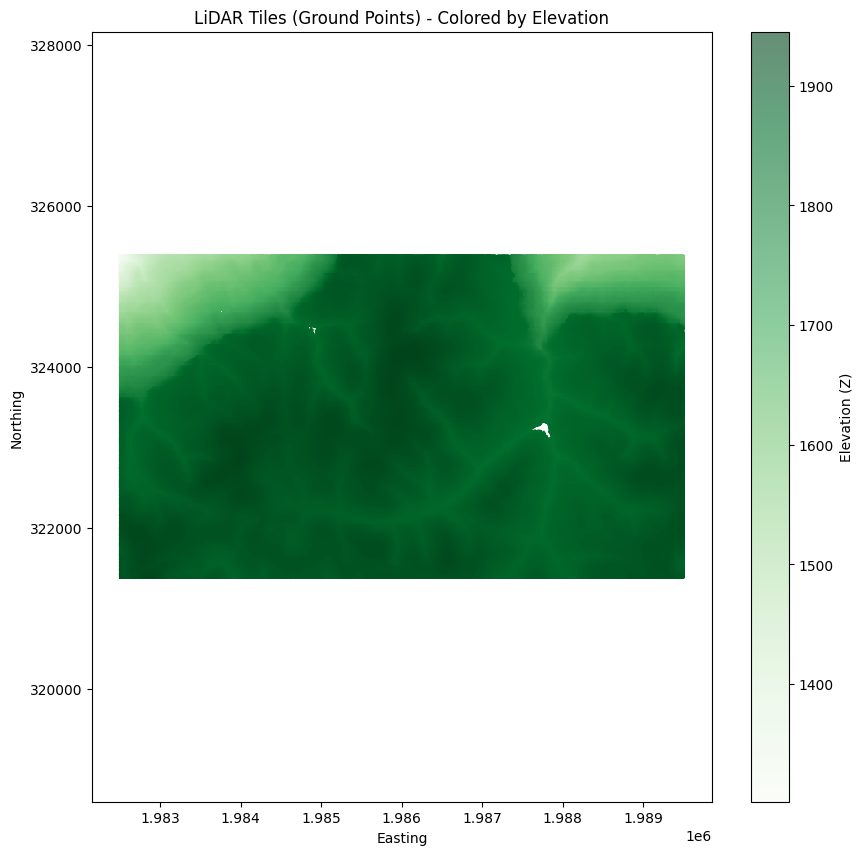

In [14]:
# # Function to read LAS and extract XYZ points (optionally filtering to ground points)
# def read_las_xyz(filename, ground_only=True):
#     las = laspy.read(filename)
#     x = las.x
#     y = las.y
#     z = las.z

#     if ground_only and "classification" in las.point_format.dimension_names:
#         mask = las.classification == 2  # 2 = ground
#         x = x[mask]
#         y = y[mask]
#         z = z[mask]

#     return x, y, z

# # Aggregate points from all LAS tiles
# all_x, all_y, all_z = [], [], []
# for f in local_files:
#     try:
#         x, y, z = read_las_xyz(f, ground_only=True)
#         all_x.append(x)
#         all_y.append(y)
#         all_z.append(z)
#     except Exception as e:
#         print(f"⚠️ Skipping {f}: {e}")

# all_x = np.concatenate(all_x)
# all_y = np.concatenate(all_y)
# all_z = np.concatenate(all_z)

# # Quick visualization with Z as color
# plt.figure(figsize=(10, 10))
# sc = plt.scatter(all_x, all_y, c=all_z, cmap='Greens', s=0.5, alpha=0.6)
# plt.title("LiDAR Tiles (Ground Points) - Colored by Elevation")
# plt.xlabel("Easting")
# plt.ylabel("Northing")
# plt.axis("equal")
# plt.colorbar(sc, label="Elevation (Z)")
# plt.show()


3d Viz of Intensity and Z

Computationally  intensive to commented off for run all. Comment on if you want to run

In [16]:

# Path to local folder where .las files are stored
folder = "/content/drive/MyDrive/GEDI_LAS_Comp"

# Get all LAS files (case-insensitive)
las_files = glob.glob(f"{folder}/*.las") + glob.glob(f"{folder}/*.LAS")
print(f"Found {len(las_files)} LAS files")

# ---------------------------
# Step 1: Load LAS data (with sampling + copy to local)
# ---------------------------
points = []
intensity = []

def load_las_points(filepath, n_points=50000):
    """Copy LAS file locally, read with laspy, return sampled xyz + intensity."""
    local_file = "/content/temp.las"
    shutil.copy(filepath, local_file)
    las = laspy.read(local_file)

    xyz = np.vstack((las.x, las.y, las.z)).T
    intens = las.intensity

    # Random sampling
    if xyz.shape[0] > n_points:
        idx = np.random.choice(xyz.shape[0], n_points, replace=False)
        xyz = xyz[idx]
        intens = intens[idx]

    return xyz, intens

for i, file in enumerate(las_files):
    print(f"Loading {i+1}/{len(las_files)}: {os.path.basename(file)}")
    try:
        xyz, intens = load_las_points(file, n_points=30000)
        points.append(xyz)
        intensity.append(intens)
    except Exception as e:
        print(f"❌ Failed to load {file}: {e}")

points = np.vstack(points)
intensity = np.hstack(intensity)
z_values = points[:, 2]

print("Loaded points:", points.shape)
print("Intensity range:", intensity.min(), "-", intensity.max())
print("Z (elevation) range:", z_values.min(), "-", z_values.max())

# ---------------------------
# Step 2: Downsample (across all files, for plotting speed)
# ---------------------------
max_points = 100000  # adjust for responsiveness
if points.shape[0] > max_points:
    sample_idx = np.random.choice(points.shape[0], size=max_points, replace=False)
    sample_points = points[sample_idx]
    sample_intensity = intensity[sample_idx]
    sample_z = z_values[sample_idx]
else:
    sample_points, sample_intensity, sample_z = points, intensity, z_values

print("Sample of X:", sample_points[:5,0])
print("Sample of Y:", sample_points[:5,1])
print("Sample of Z:", sample_points[:5,2])
print("Intensity sample:", sample_intensity[:5])
print("Number of points to plot:", sample_points.shape[0])

# ---------------------------
# Step 2.5: Normalize XY for plotting (shift to origin and convert to km)
# ---------------------------
norm_points = sample_points.copy()
norm_points[:, 0] -= norm_points[:, 0].min()
norm_points[:, 1] -= norm_points[:, 1].min()

# optional: scale XY to kilometers for nicer axes
norm_points[:, 0] /= 1000.0
norm_points[:, 1] /= 1000.0

# ---------------------------
# Step 3: Plot function
# ---------------------------
def plot_pointcloud(points, values, title, cmap="Viridis"):
    fig = go.Figure(data=[go.Scatter3d(
        x=points[:,0],
        y=points[:,1],
        z=points[:,2],
        mode='markers',
        marker=dict(
            size=2,
            color=values,
            colorscale=cmap,
            opacity=0.7
        )
    )])

    fig.update_layout(
        scene=dict(
            xaxis_title="X (km)",
            yaxis_title="Y (km)",
            zaxis_title="Z (m)"
        ),
        title=title,
        height=800
    )
    fig.show()

# ---------------------------
# Step 4: Plot by Intensity
# ---------------------------
plot_pointcloud(norm_points, sample_intensity,
                title="Interactive LiDAR Point Cloud (Colored by Intensity, Normalized XY)",
                cmap="Inferno")

# ---------------------------
# Step 5: Plot by Elevation (Z)
# ---------------------------
plot_pointcloud(norm_points, sample_z,
                title="Interactive LiDAR Point Cloud (Colored by Elevation / Z, Normalized XY)",
                cmap="Viridis")


Found 1 LAS files
Loading 1/1: 1982317NW.las
Loaded points: (30000, 3)
Intensity range: 0 - 65535
Z (elevation) range: 1315.67 - 2018.6000000000001
Sample of X: [1988099.27 1988336.77 1987038.71 1984984.27 1985033.49]
Sample of Y: [322027.84 325204.53 322835.31 323846.85 324504.63]
Sample of Z: [1894.75 1599.63 1867.02 1889.52 1869.07]
Intensity sample: [42500  8295 28550 58700 46100]
Number of points to plot: 30000


# Fetch and Download GEDI CSVs from module 2

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.16929466.svg)](https://doi.org/10.5281/zenodo.16929466)


see and fecth dataset: https://zenodo.org/records/16929466

In [12]:
record_id = "16929466"
# For restricted access, you'd need an access token
# ACCESS_TOKEN = "YOUR_ZENODO_ACCESS_TOKEN"

# Fetch record metadata to get file links
r = requests.get(f"https://zenodo.org/api/records/{record_id}") # , params={'access_token': ACCESS_TOKEN}
r.raise_for_status()
files = r.json()['files']

# Download each file
for file_info in files:
    filename = file_info['key']
    download_url = file_info['links']['self']

    with requests.get(download_url, stream=True) as r_file:
        r_file.raise_for_status()
        with open(filename, 'wb') as f:
            for chunk in r_file.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded: {filename}")

Downloaded: GEDI_csvs.zip


In [13]:
!unzip /content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs.zip

Archive:  /content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs.zip
   creating: GEDI_csvs/.ipynb_checkpoints/
  inflating: GEDI_csvs/PaintRock_AOI_Variables_selected_subset_GEDI02_B.csv  
  inflating: GEDI_csvs/Sewanee_Domain_Variables_selected_subset_GEDI02_B.csv  
  inflating: GEDI_csvs/SPB_AOI_Variables_selected_subset_GEDI02_B.csv  
  inflating: GEDI_csvs/Prescribed_Burn_AOI_Variables_selected_subset_GEDI02_B.csv  


Note the differing CRS (LAS and GEDI) reporjeciton part of the workflow

Open CSV

In [ ]:
# gedi = pd.read_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/Sewanee_Domain_Variables_selected_subset_GEDI02_B.csv")
# # print(gedi.head())

# gedi_gdf = gpd.GeoDataFrame(
#     gedi,
#     geometry=gpd.points_from_xy(gedi['lon'], gedi['lat']),
#     crs="EPSG:4326" ### converting to make the particular TN las files "EPSG:4326"  # WGS84
# )

# # # gedi_gdf

# # # Buffer each point by 25 (units = CRS units, so 25 in EPSG:6576)
# # gedi_gdf['geometry'] = gedi_gdf.buffer(25)

# # Save back if needed
# gedi_gdf.to_file("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/gedi_buffers.geojson", driver="GeoJSON")

# # Show first few rows
# # gedi_gdf.head()

# gedi_gdf

# Clip GEDI to bounds of Las (reduce processing)

In [9]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import laspy
from pyproj import CRS

# --- Step 1: Load LAS and get bounding box ---
las = laspy.read("/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW.las")

minx, maxx = las.x.min(), las.x.max()
miny, maxy = las.y.min(), las.y.max()

# Create bounding box polygon in LAS CRS (EPSG:6576)
las_crs = CRS.from_epsg(6576)
bbox_poly = gpd.GeoSeries([box(minx, miny, maxx, maxy)], crs=las_crs)

# --- Step 2: Reproject bounding box to EPSG:4326 ---
bbox_poly_wgs84 = bbox_poly.to_crs(epsg=4326)

# --- Step 3: Load CSV points ---
df = pd.read_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/Sewanee_Domain_Variables_selected_subset_GEDI02_B.csv")

# Assuming CSV has columns 'longitude' and 'latitude' (adjust if names differ)
gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# --- Step 4: Clip points to LAS bounding box ---
clipped_points = gdf_points[gdf_points.within(bbox_poly_wgs84.iloc[0])]

# --- Step 5: Save / use result ---
clipped_points.to_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/clipped_points.csv", index=False)

print(f"Original points: {len(df)}")
print(f"Clipped points: {len(clipped_points)}")


Original points: 31982
Clipped points: 560


View the clipped GEDI Csv to the .las bounds

In [10]:
clipped_points

,lat,lon,geolocation/solar_elevation,geolocation/local_beam_elevation,selected_l2a_algorithm,geolocation/degrade_flag,l2b_quality_flag,geolocation/digital_elevation_model,geolocation/elev_lowestmode,geolocation/elev_highestreturn,...,pai_z,fhd_normal,pavd_z,cover,cover_z,product,Beam,fileName,date,geometry
2973,35.226645,-85.952191,6.331068,1.485489,2,0,0,428.120880,4913.635254,4954.624512,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM1000,GEDI02_B_2024169103448_O31228_02_T05264_02_004...,2024-06-17,POINT (-85.95219 35.22665)
2974,35.227000,-85.951722,6.331578,1.485489,2,0,0,446.815247,4924.188477,4942.406250,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM1000,GEDI02_B_2024169103448_O31228_02_T05264_02_004...,2024-06-17,POINT (-85.95172 35.227)
2978,35.225911,-85.952789,6.330425,1.485430,2,0,1,459.937866,447.504364,454.635834,...,"[1.1548267602920532, 0.2481711506843567, -0.0,...",1.849289,"[0.18133112788200378, 0.11548267304897308, 0.0...",0.438233,"[0.43823322653770447, 0.11666984111070633, 0.0...",GEDI_L2B,BEAM1000,GEDI02_B_2024169103448_O31228_02_T05264_02_004...,2024-06-17,POINT (-85.95279 35.22591)
2979,35.226252,-85.952335,6.330932,1.485430,2,0,1,428.120880,433.156586,444.805939,...,"[2.821882963180542, 1.4518966674804688, 0.0769...",2.352788,"[0.2739972770214081, 0.2744947075843811, 0.145...",0.754583,"[0.7545831799507141, 0.5155324339866638, 0.037...",GEDI_L2B,BEAM1000,GEDI02_B_2024169103448_O31228_02_T05264_02_004...,2024-06-17,POINT (-85.95234 35.22625)
3083,35.220260,-85.950702,6.329217,1.486232,2,0,0,568.325562,4915.318359,4938.688965,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM1011,GEDI02_B_2024169103448_O31228_02_T05264_02_004...,2024-06-17,POINT (-85.9507 35.22026)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30073,35.217706,-85.952183,-25.604811,1.556796,1,0,0,574.444214,3586.643555,3586.643555,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM0000,GEDI02_B_2021139070445_O13780_03_T06003_02_003...,2021-05-19,POINT (-85.95218 35.21771)
30074,35.217357,-85.951724,-25.604849,1.556796,1,0,0,574.863342,3586.257568,3586.257568,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM0000,GEDI02_B_2021139070445_O13780_03_T06003_02_003...,2021-05-19,POINT (-85.95172 35.21736)
30075,35.217008,-85.951265,-25.604887,1.556796,1,0,0,574.485535,3586.491211,3586.491211,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM0000,GEDI02_B_2021139070445_O13780_03_T06003_02_003...,2021-05-19,POINT (-85.95126 35.21701)
30076,35.216658,-85.950806,-25.604925,1.556796,1,0,0,571.842834,3586.127930,3586.127930,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM0000,GEDI02_B_2021139070445_O13780_03_T06003_02_003...,2021-05-19,POINT (-85.95081 35.21666)


Display this on a map to verify

Computationally  intensive to commented off for run all. Comment on if you want to run

In [18]:
# import pandas as pd
# import geopandas as gpd
# import folium

# # --- Load clipped points as plain DataFrame ---
# df = pd.read_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/clipped_points.csv")

# # --- Convert to GeoDataFrame ---
# gdf = gpd.GeoDataFrame(
#     df,
#     geometry=gpd.points_from_xy(df.lon, df.lat),
#     crs="EPSG:4326"
# )

# # --- Create folium map ---
# m = folium.Map(
#     location=[gdf.geometry.y.mean(), gdf.geometry.x.mean()],
#     zoom_start=12
# )

# # Add points as circle markers
# for _, row in gdf.iterrows():
#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x],
#         radius=2,
#         color="green",
#         fill=True,
#         fill_opacity=0.7
#     ).add_to(m)

# m


Buffer gedi to 25m diamater plots | requirirng a reprojeciton

In [11]:
import pandas as pd
import geopandas as gpd

# --- Step 1: Load CSV into GeoDataFrame ---
df = pd.read_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/clipped_points.csv")
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# --- Step 2: Reproject to UTM (zone 16N covers Tennessee) ---
gdf_utm = gdf.to_crs(epsg=26916)

# --- Step 3: Buffer points by 12.5 meters (25 m diameter) ---
gdf_utm["Plot"] = gdf_utm.geometry.buffer(12.5)

# --- Step 4: Reproject back to EPSG:4326 for saving/visualization ---
gdf_out = gdf_utm.to_crs(epsg=4326)

# Keep original point geometry AND Plot polygons
gdf_out["geometry"] = gdf.geometry  # restore original point geom
# Polygons are in new "Plot" column


Odd Hack
to save this buffered CSV need to drop "geometry" if intrested in chekc poitns run these to produce this geojson

In [ ]:
# gdf_out = gdf_out.drop('geometry', axis=1)
# gdf_out

In [32]:
# print(gdf_out.columns.tolist())

['lat', 'lon', 'geolocation/solar_elevation', 'geolocation/local_beam_elevation', 'selected_l2a_algorithm', 'geolocation/degrade_flag', 'l2b_quality_flag', 'geolocation/digital_elevation_model', 'geolocation/elev_lowestmode', 'geolocation/elev_highestreturn', 'rh100', 'shot_number', 'num_detectedmodes', 'sensitivity', 'land_cover_data/leaf_off_flag', 'pgap_theta_z', 'pai', 'pai_z', 'fhd_normal', 'pavd_z', 'cover', 'cover_z', 'product', 'Beam', 'fileName', 'date', 'Plot']


In [31]:
# # # --- Step 5: Save ---
# gdf_out.to_file("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/clipped_points_with_plots.geojson", driver="GeoJSON")

Add to map to verfiy

Computationally  intensive to commented off for run all. Comment on if you want to run

In [35]:
# import folium
# import geopandas as gpd

# # Points are WGS84
# gdf_out = gdf_out.set_crs("EPSG:4326", allow_override=True)

# # --- Build polygon GeoDataFrame from the Plot column (which is in EPSG:26916) ---
# # Keep only safe/simple attributes to avoid JSON serialization issues
# wanted = [c for c in ["lat","lon","product","Beam","fileName","date"] if c in gdf_out.columns]

# plots_utm = gpd.GeoDataFrame(
#     gdf_out[wanted].copy(),      # <- no geometry columns here
#     geometry=gdf_out["Plot"],    # <- make Plot the active geometry
#     crs="EPSG:26916"
# )

# # Reproject polygons to WGS84 for web mapping
# plots = plots_utm.to_crs(epsg=4326)

# # (Optional) absolutely safest: only geometry, no properties
# plots_simple = plots[["geometry"]].copy()

# # --- Initialize map (fit to polygon bounds) ---
# m = folium.Map(zoom_start=14)
# minx, miny, maxx, maxy = plots.total_bounds
# m.fit_bounds([[miny, minx], [maxy, maxx]])

# # --- Add polygons (use a minimal GeoJSON to avoid serialization errors) ---
# folium.GeoJson(
#     data=plots_simple.to_json(),   # <- only geometry, no complex properties
#     name="25 m Plots",
#     style_function=lambda f: {"color": "blue", "weight": 1, "fillOpacity": 0.2}
# ).add_to(m)

# # --- Add the original point markers ---
# for _, row in gdf_out.iterrows():
#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x],
#         radius=3,
#         color="red",
#         fill=True,
#         fill_opacity=0.8
#     ).add_to(m)

# folium.LayerControl().add_to(m)
# m


# Bring the GEDI and ALS together

30-40 minute run time

In [36]:
import laspy
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# -----------------------------
# Step 1: Prepare GEDI Plots
# -----------------------------
gdf_out = gdf_out.set_crs("EPSG:4326", allow_override=True)

plots = gpd.GeoDataFrame(
    gdf_out.drop(columns="geometry"),  # drop original point geometry
    geometry=gdf_out["Plot"],          # keep Plot polygons
    crs="EPSG:26916"                   # Plot polygons created in UTM 16N
)

# Reproject to WGS84 for matching LAS points
plots_wgs = plots.to_crs(epsg=4326)

# -----------------------------
# Step 2: Open LAS file in chunks
# -----------------------------
las_file = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW.las"
results = []
chunk_size = 2_000_000  # 2M points per chunk

# Get bounding box of all plots in LAS CRS (EPSG:6576)
plots_bbox = plots.to_crs(epsg=6576).total_bounds  # [minx, miny, maxx, maxy]

with laspy.open(las_file) as lasf:
    for chunk in lasf.chunk_iterator(chunk_size):
        # Extract XYZ as numpy arrays
        x = np.array(chunk.x)
        y = np.array(chunk.y)
        z = np.array(chunk.z)

        # -----------------------------
        # Step 3: Filter by bounding box
        # -----------------------------
        mask = (
            (x >= plots_bbox[0]) & (x <= plots_bbox[2]) &
            (y >= plots_bbox[1]) & (y <= plots_bbox[3])
        )
        if not mask.any():
            continue  # skip empty chunks

        # -----------------------------
        # Step 4: Make GeoDataFrame
        # -----------------------------
        las_df = pd.DataFrame({"X": x[mask], "Y": y[mask], "Z": z[mask]})
        las_gdf = gpd.GeoDataFrame(
            las_df,
            geometry=gpd.points_from_xy(las_df["X"], las_df["Y"]),
            crs="EPSG:6576"  # LAS CRS
        ).to_crs(epsg=4326)   # reproject to WGS84

        # -----------------------------
        # Step 5: Spatial join with plots
        # -----------------------------
        las_in_chunk = gpd.sjoin(las_gdf, plots_wgs, how="inner", predicate="within")

        if not las_in_chunk.empty:
            # Keep LAS points as active geometry
            las_in_chunk = las_in_chunk.set_geometry("geometry")
            # Convert Plot polygon to WKT for reference
            las_in_chunk["Plot_WKT"] = las_in_chunk["Plot"].apply(lambda p: p.wkt)
            # Drop original Plot geometry to avoid GeoJSON errors
            las_in_chunk = las_in_chunk.drop(columns="Plot")
            results.append(las_in_chunk)

# -----------------------------
# Step 6: Concatenate all chunks
# -----------------------------
if results:
    las_in_plots = pd.concat(results, ignore_index=True)
    print(f"✅ Total LAS points inside GEDI plots: {len(las_in_plots)}")
else:
    las_in_plots = gpd.GeoDataFrame(columns=las_gdf.columns)
    print("⚠️ No LAS points found inside plots")

# -----------------------------
# Step 7: Save results
# -----------------------------
# GeoJSON (geometry = LAS points)
las_in_plots.to_file("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/las_in_plots.geojson", driver="GeoJSON")
# CSV (all attributes including Plot WKT)
las_in_plots.to_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/las_in_plots.csv", index=False)


✅ Total LAS points inside GEDI plots: 2265679


# Check Point:
Due to the limiaitons of the Colab and aviabale Ram the steps above have bene consolidated to thsi derived product



Fetch Check Point

see and fetch :

In [ ]:
# record_id = #"16929466"
# # For restricted access, you'd need an access token
# # ACCESS_TOKEN = "YOUR_ZENODO_ACCESS_TOKEN"

# # Fetch record metadata to get file links
# r = requests.get(f"https://zenodo.org/api/records/{record_id}") # , params={'access_token': ACCESS_TOKEN}
# r.raise_for_status()
# files = r.json()['files']

# # Download each file
# for file_info in files:
#     filename = file_info['key']
#     download_url = file_info['links']['self']

#     with requests.get(download_url, stream=True) as r_file:
#         r_file.raise_for_status()
#         with open(filename, 'wb') as f:
#             for chunk in r_file.iter_content(chunk_size=8192):
#                 f.write(chunk)
#         print(f"Downloaded: {filename}")

Plot the corelation for the .las avergaed Z value per 25m plot and the GEDI rh100 value

In [12]:
# import pandas as pd
# import geopandas as gpd

# # -----------------------------
# # Step 1: Load CSV with rh100 per plot
# # -----------------------------
# gdf_out = gdf_out.set_crs("EPSG:4326", allow_override=True)
# plots = gpd.GeoDataFrame(
#     gdf_out.drop(columns="geometry"),
#     geometry=gdf_out["Plot"],          # polygons are in the "Plot" column
#     crs="EPSG:26916"
# )

# # Assign a unique Plot ID to each polygon for grouping
# plots["Plot_ID"] = range(len(plots))

# # Reproject to WGS84 (to match LAS points)
# plots_wgs = plots.to_crs(epsg=4326)

# # -----------------------------
# # Step 2: Load LAS points inside plots
# # -----------------------------
# las_in_plots = pd.read_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/las_in_plots.csv")

# # Convert LAS points to GeoDataFrame
# las_gdf = gpd.GeoDataFrame(
#     las_in_plots,
#     geometry=gpd.points_from_xy(las_in_plots.X, las_in_plots.Y),
#     crs="EPSG:4326"
# )

# # -----------------------------
# # Step 3: Spatial join to assign Plot_ID to each LAS point
# # -----------------------------
# las_with_plot = gpd.sjoin(
#     las_gdf,
#     plots_wgs[["Plot_ID", "geometry"]],
#     how="inner",
#     predicate="within",
#     lsuffix="las",
#     rsuffix="plot"
# )

# # -----------------------------
# # Step 4: Compute average LAS Z per plot
# # -----------------------------
# avg_las_per_plot = las_with_plot.groupby("Plot_ID")["Z"].mean().reset_index()
# avg_las_per_plot.rename(columns={"Z": "avg_las_plot"}, inplace=True)

# # -----------------------------
# # Step 5: Merge with GEDI rh100
# # -----------------------------
# plots_rh100 = plots[["Plot_ID", "rh100"]]  # ensure we keep Plot_ID + rh100

# correlation_df = pd.merge(
#     plots_rh100,
#     avg_las_per_plot,
#     on="Plot_ID",
#     how="inner"
# )

# print(correlation_df.head())
# print(f"✅ Correlation dataframe ready with {len(correlation_df)} plots")


Empty DataFrame
Columns: [Plot_ID, rh100, avg_las_plot]
Index: []
✅ Correlation dataframe ready with 0 plots


In [13]:
import pandas as pd

# -----------------------------
# Step 1: Load LAS–GEDI merged CSV
# -----------------------------
las_in_plots = pd.read_csv("/content/drive/MyDrive/GEDI_LAS_Comp/GEDI_csvs/las_in_plots.csv")

# Quick check of available columns
print("CSV columns:", las_in_plots.columns.tolist())

# -----------------------------
# Step 2: Compute avg LAS Z per plot
# -----------------------------
# If there's already a unique plot identifier in the CSV, use it.
# Otherwise, group by 'Plot_WKT' (or another plot field).
group_field = "Plot_WKT" if "Plot_WKT" in las_in_plots.columns else "Plot_ID"

avg_las_per_plot = (
    las_in_plots.groupby(group_field)["Z"]
    .mean()
    .reset_index()
    .rename(columns={"Z": "avg_las_plot"})
)

# -----------------------------
# Step 3: Extract unique rh100 per plot
# -----------------------------
rh100_per_plot = (
    las_in_plots.groupby(group_field)["rh100"]
    .first()  # all rows in a plot share same rh100
    .reset_index()
)

# -----------------------------
# Step 4: Merge into correlation dataframe
# -----------------------------
correlation_df = pd.merge(rh100_per_plot, avg_las_per_plot, on=group_field, how="inner")

print(correlation_df.head())
print(f"✅ Correlation dataframe ready with {len(correlation_df)} plots")

# -----------------------------
# Step 5 (Optional): Compute correlation coefficient
# -----------------------------
corr_value = correlation_df["rh100"].corr(correlation_df["avg_las_plot"])
print(f"📈 Pearson correlation (rh100 vs avg_las_plot): {corr_value:.3f}")


CSV columns: ['X', 'Y', 'Z', 'geometry', 'index_right', 'lat', 'lon', 'geolocation/solar_elevation', 'geolocation/local_beam_elevation', 'selected_l2a_algorithm', 'geolocation/degrade_flag', 'l2b_quality_flag', 'geolocation/digital_elevation_model', 'geolocation/elev_lowestmode', 'geolocation/elev_highestreturn', 'rh100', 'shot_number', 'num_detectedmodes', 'sensitivity', 'land_cover_data/leaf_off_flag', 'pgap_theta_z', 'pai', 'pai_z', 'fhd_normal', 'pavd_z', 'cover', 'cover_z', 'product', 'Beam', 'fileName', 'date', 'Plot_WKT']
                                            Plot_WKT  rh100  avg_las_plot
0  POLYGON ((595285.5602062192 3898466.759217509,...   4604   1641.097713
1  POLYGON ((595291.0913920404 3897765.749965638,...      0   1945.339247
2  POLYGON ((595294.7291942913 3898688.3000771035...    880   1415.522983
3  POLYGON ((595297.0786733279 3897699.1083609597...      0   1947.972296
4  POLYGON ((595298.0675551336 3898120.9037817526...   2530   1913.077312
✅ Correlation datafra

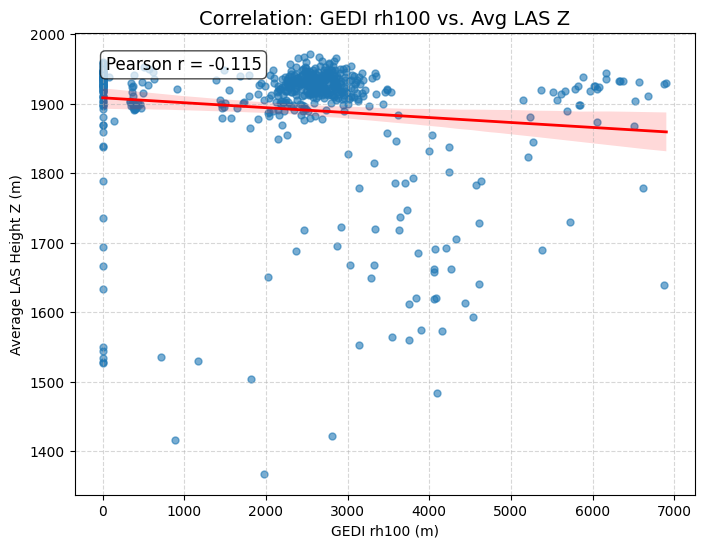

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Scatterplot with regression line
# -----------------------------
plt.figure(figsize=(8, 6))
sns.regplot(
    data=correlation_df,
    x="rh100",
    y="avg_las_plot",
    scatter_kws={"s": 25, "alpha": 0.6},  # smaller, semi-transparent points
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Correlation: GEDI rh100 vs. Avg LAS Z", fontsize=14)
plt.xlabel("GEDI rh100 (m)")
plt.ylabel("Average LAS Height Z (m)")
plt.grid(True, linestyle="--", alpha=0.5)

# Show correlation value on plot
plt.text(
    0.05, 0.95,
    f"Pearson r = {correlation_df['rh100'].corr(correlation_df['avg_las_plot']):.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)

plt.show()
